In [12]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [13]:
# Load training images from directory, resize all images to 224x224, and assign categorical labels (one-hot encoding)
training_dataset = tf.keras.utils.image_dataset_from_directory(
    "/home/navi/College/Code/Datasets/brainMRI/Training/",
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical'
)

# Load testing images with same preprocessing settings; shuffle=False ensures consistent evaluation order
testing_dataset = tf.keras.utils.image_dataset_from_directory(
    "/home/navi/College/Code/Datasets/brainMRI/Testing/",
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

# Apply model-specific preprocessing (normalization matching ImageNet-trained CNNs like EfficientNet/ResNet)
# This ensures pixel values are transformed into the format expected by pretrained networks
training_dataset = training_dataset.map(lambda x, y: (preprocess_input(x), y))
testing_dataset = testing_dataset.map(lambda x, y: (preprocess_input(x), y))

# Load EfficientNetB0 pretrained on ImageNet without the classification head (feature extractor mode)
effNet = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# Load ResNet50 pretrained on ImageNet without the classification head (feature extractor mode)
resNet = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# for images, labels in testing_dataset.take(1):
#     print(images.shape)
# for images, labels in testing_dataset.take(1):
#     plt.imshow(images[0].numpy().astype("uint8"))
#     plt.title("Sample Image")
#     plt.show()

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


1/1 [==============================] - 0s 34ms/step
E2E Pretrained + SVM training time (secs): 44.40
Accuracy: 0.94375
              precision    recall  f1-score   support

           0       0.99      0.79      0.88       400
           1       0.86      0.98      0.92       400
           2       0.95      1.00      0.98       400
           3       0.99      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600

[[317  62  18   3]
 [  3 393   2   2]
 [  0   0 400   0]
 [  0   0   0 400]]


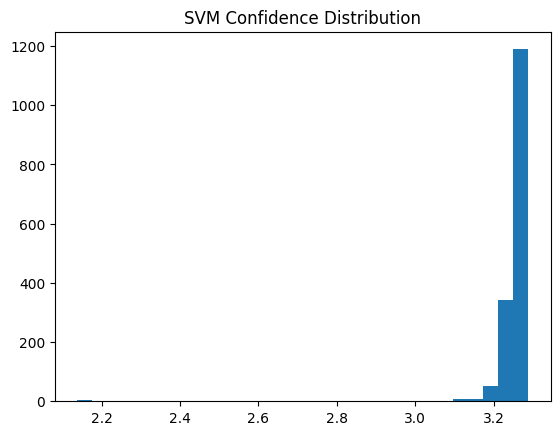

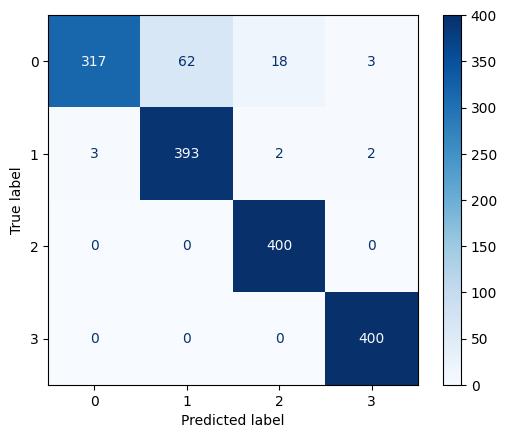

In [ ]:
# Approach 1: Pretrained Model + SVM
# Freeze EfficientNet weights so it acts as a fixed feature extractor (no training)
startTime = time.time()
effNet.trainable = False

# Add global average pooling to convert feature maps into 1D feature vectors
effNetPooling = tf.keras.Sequential([
    effNet,
    tf.keras.layers.GlobalAveragePooling2D()
])

# Initialize lists to store extracted features and labels
X_train, y_train = [], []
X_test, y_test = [], []

# Extract deep feature representations from EfficientNet for training set
for images, labels in training_dataset:
    features = effNetPooling.predict(images)  # forward pass through CNN
    X_train.append(features)
    y_train.append(labels.numpy())

# Extract deep feature representations from EfficientNet for test set
for images, labels in testing_dataset:
    features = effNetPooling.predict(images)
    X_test.append(features)
    y_test.append(labels.numpy())

# Convert lists into full NumPy arrays for ML model input
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

# Standardize feature vectors to improve SVM performance (zero mean, unit variance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert one-hot encoded labels into class indices
y_train = np.argmax(y_train, axis=1)
y_test = np.argmax(y_test, axis=1)

# Train Support Vector Machine classifier on extracted CNN features
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)
endTime = time.time()

# Predict class labels for test set
y_pred = svm.predict(X_test)

print(f"(EffNet) E2E Pretrained + SVM training time (secs): {endTime - startTime:.2f}")

# Print classification metrics for evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Get decision function scores (distance from hyperplane) for confidence analysis
distances = svm.decision_function(X_test)

# Plot distribution of model confidence scores
plt.hist(np.max(distances, axis=1), bins=30)
plt.title("SVM Confidence Distribution")
plt.show()

# Visualize confusion matrix of predictions
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

Epoch 1/5


2026-05-13 17:40:09.608868: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


175/175 [==============================] - 39s 177ms/step - loss: 0.6595 - accuracy: 0.7557 - val_loss: 0.4538 - val_accuracy: 0.8506
Epoch 2/5
175/175 [==============================] - 30s 171ms/step - loss: 0.2805 - accuracy: 0.8964 - val_loss: 0.3361 - val_accuracy: 0.8944
Epoch 3/5
175/175 [==============================] - 30s 171ms/step - loss: 0.1826 - accuracy: 0.9330 - val_loss: 0.3105 - val_accuracy: 0.9150
Epoch 4/5
175/175 [==============================] - 30s 172ms/step - loss: 0.1395 - accuracy: 0.9493 - val_loss: 0.3329 - val_accuracy: 0.9162
Epoch 5/5
1/1 [==============================] - 0s 29ms/step
E2E Pretrained training time (secs): 159.02
Accuracy:  0.918749988079071
              precision    recall  f1-score   support

           0       0.97      0.75      0.85       400
           1       0.82      0.96      0.89       400
           2       0.91      1.00      0.95       400
           3       1.00      0.96      0.98       400

    accuracy               

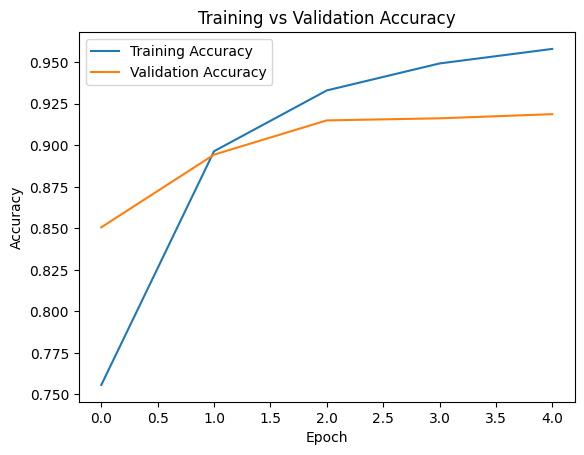

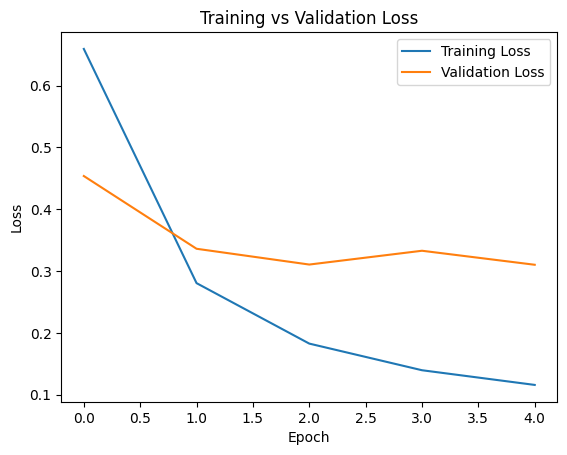

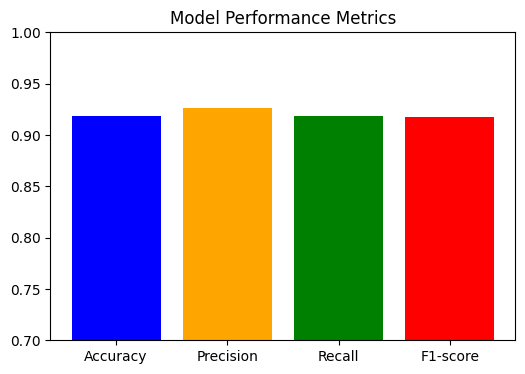

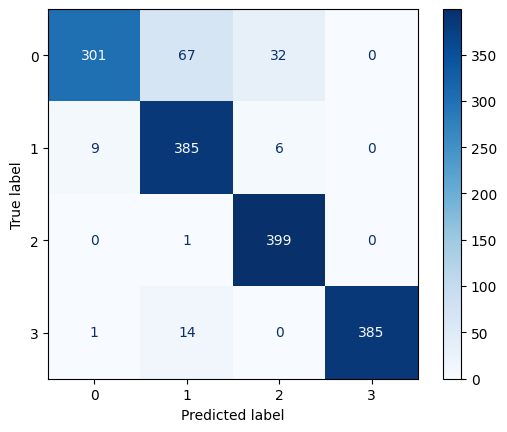

In [ ]:
# Approach 2: End-to-End Pretrained Model
effNet.trainable = True
for layer in effNet.layers[:-20]:
    layer.trainable = False

# Build full classification model using EfficientNet backbone + custom classifier head
effNetComplete = tf.keras.Sequential([
    effNet,  # pretrained feature extractor
    tf.keras.layers.GlobalAveragePooling2D(),  # convert feature maps to vector
    tf.keras.layers.BatchNormalization(),       # stabilize training
    tf.keras.layers.Dense(128, activation='relu'),  # learn non-linear patterns
    tf.keras.layers.Dropout(0.3),              # reduce overfitting
    tf.keras.layers.Dense(4, activation='softmax')   # final multi-class output
])

# Compile model with Adam optimizer and categorical crossentropy loss (multi-class classification)
effNetComplete.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model and store training history for visualization
startTime = time.time()
history = effNetComplete.fit(
    training_dataset,
    validation_data=testing_dataset,
    epochs=10  # increase to 10 for final experiment
)
endTime = time.time()

# Evaluate final model performance on test dataset
loss, acc = effNetComplete.evaluate(testing_dataset)

# Collect true and predicted labels for detailed evaluation metrics
y_test = []
y_pred = []

# Run inference on test dataset batch by batch
for images, labels in testing_dataset:
    preds = effNetComplete.predict(images)
    y_test.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(f"(EffNet) E2E Pretrained training time (secs): {endTime - startTime:.2f}")
# Print classification metrics (precision, recall, F1-score, accuracy)
print("Accuracy: ", acc)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Plot training vs validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Plot training vs validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Compute and visualize overall classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values, color=['blue','orange','green','red'])
plt.ylim(0.7,1.0)
plt.title("Model Performance Metrics")
plt.show()

# Confusion matrix visualization for class-wise performance analysis
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

# Save trained model for deployment / GUI integration
effNetComplete.save("effNet.keras")

1/1 [==============================] - 0s 25ms/step
E2E Pretrained + SVM training time (secs): 69.22
Accuracy: 0.9375
              precision    recall  f1-score   support

           0       0.99      0.77      0.87       400
           1       0.85      0.99      0.91       400
           2       0.95      1.00      0.97       400
           3       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600

[[308  70  21   1]
 [  1 395   2   2]
 [  0   0 400   0]
 [  1   2   0 397]]


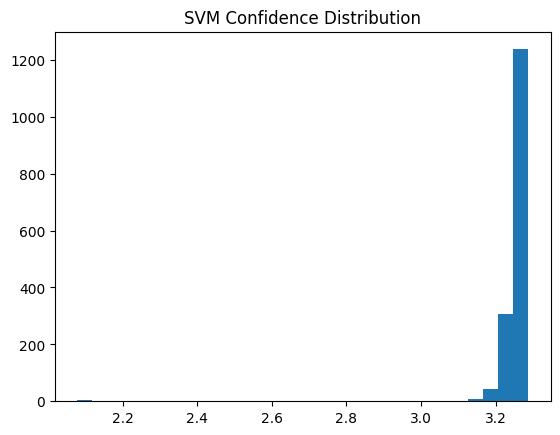

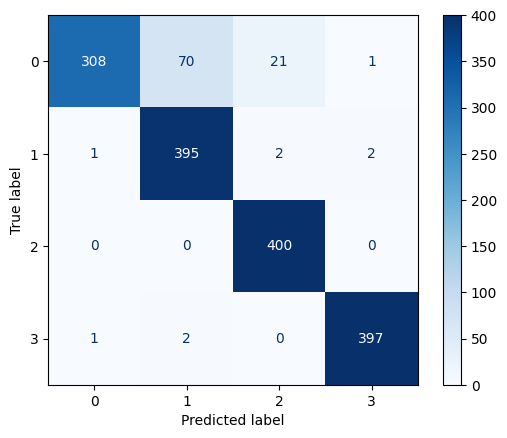

In [ ]:
# Approach 1 (Bonus): Pretrained Model + SVM
startTime = time.time()

resNet.trainable = False
resNetPooling = tf.keras.Sequential([resNet,tf.keras.layers.GlobalAveragePooling2D()])

X_train, y_train = [], []
X_test, y_test = [], []

for images, labels in training_dataset:
    features = resNetPooling.predict(images)
    X_train.append(features)
    y_train.append(labels.numpy())
for images, labels in testing_dataset:
    features = resNetPooling.predict(images)
    X_test.append(features)
    y_test.append(labels.numpy())

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = np.argmax(y_train, axis=1)
y_test = np.argmax(y_test, axis=1)

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)
endTime = time.time()

print(f"(ResNet) E2E Pretrained + SVM training time (secs): {endTime - startTime:.2f}")

y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

distances = svm.decision_function(X_test)
plt.hist(np.max(distances, axis=1), bins=30)
plt.title("SVM Confidence Distribution")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

Epoch 1/5


2026-05-13 17:44:29.710156: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-05-13 17:44:29.710207: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-05-13 17:44:29.747723: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-05-13 17:44:29.747766: W external/local_tsl/tsl/framework/bfc_

175/175 [==============================] - 54s 265ms/step - loss: 0.3882 - accuracy: 0.8662 - val_loss: 0.4499 - val_accuracy: 0.8956
Epoch 2/5
175/175 [==============================] - 46s 261ms/step - loss: 0.0844 - accuracy: 0.9721 - val_loss: 0.3155 - val_accuracy: 0.9306
Epoch 3/5
175/175 [==============================] - 46s 262ms/step - loss: 0.0351 - accuracy: 0.9900 - val_loss: 0.4520 - val_accuracy: 0.9275
Epoch 4/5
175/175 [==============================] - 46s 262ms/step - loss: 0.0261 - accuracy: 0.9927 - val_loss: 0.4262 - val_accuracy: 0.9312
Epoch 5/5
1/1 [==============================] - 0s 26ms/step
E2E Pretrained training time (secs): 237.24
Accuracy:  0.9393749833106995
              precision    recall  f1-score   support

           0       0.99      0.79      0.88       400
           1       0.87      0.99      0.93       400
           2       0.93      1.00      0.97       400
           3       0.98      0.98      0.98       400

    accuracy              

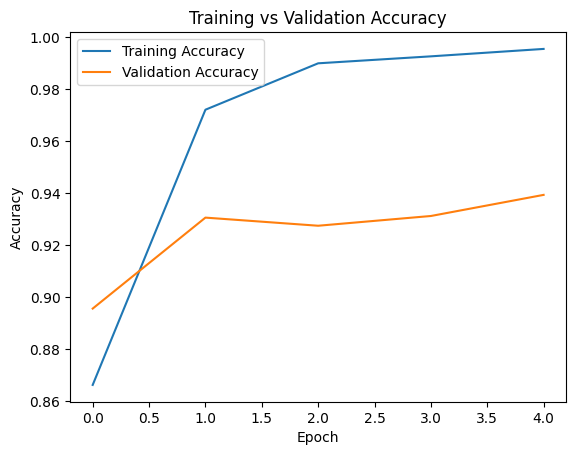

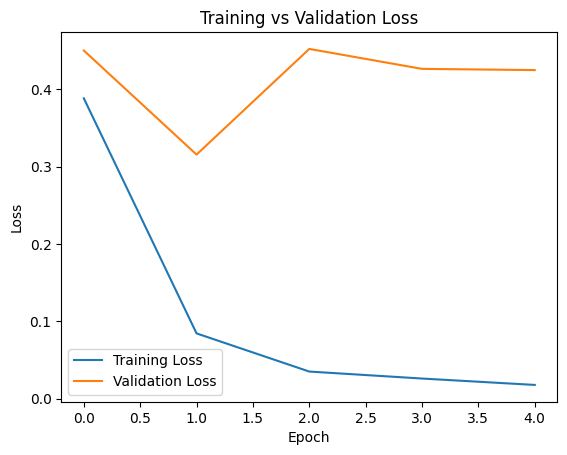

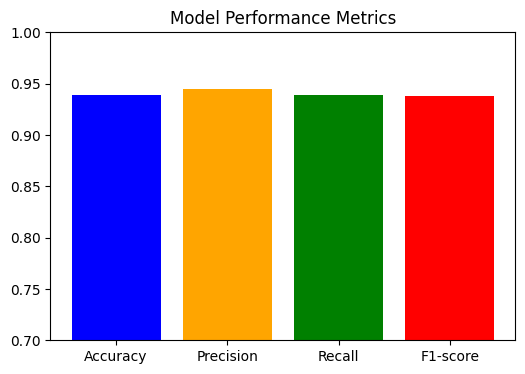

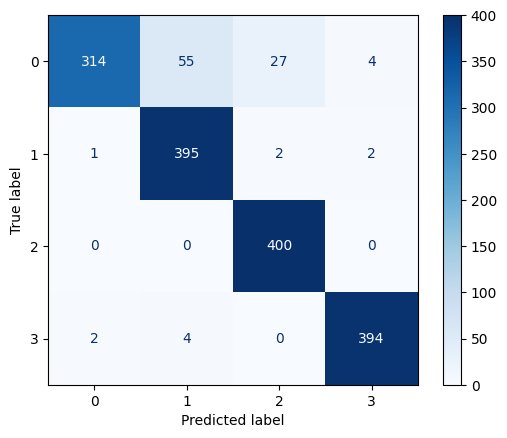

In [ ]:
# Approach 2 (Bonus): End-to-End Pretrained Model
resNet.trainable = True
for layer in resNet.layers[:-20]:
    layer.trainable = False

resNetComplete = tf.keras.Sequential([
    resNet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')
])
    
resNetComplete.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

startTime = time.time()
history = resNetComplete.fit(
    training_dataset,
    validation_data=testing_dataset,
    epochs=10 #CHANGE THIS TO 10
)
endTime = time.time()

loss, acc = resNetComplete.evaluate(testing_dataset)
y_test = []
y_pred = []

for images, labels in testing_dataset:
    preds = resNetComplete.predict(images)
    y_test.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(f"(ResNet) E2E Pretrained training time (secs): {endTime - startTime:.2f}")
print("Accuracy: ", acc)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [accuracy, precision, recall, f1]
plt.figure(figsize=(6,4))
plt.bar(metrics, values, color=['blue','orange','green','red'])
plt.ylim(0.7,1.0)
plt.title("Model Performance Metrics")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
#resNetComplete.save("resNet.keras")